Simulated annealing algorithm
Results
$\sigma$ = 0.618567
$\mu$ = 0.803221


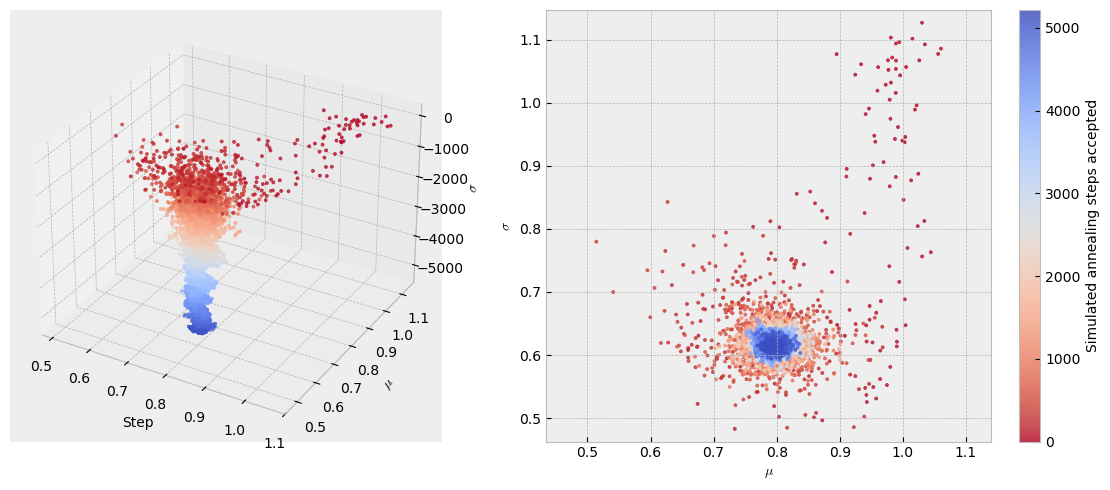

In [165]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm

data = np.loadtxt("output_SA.txt")
data_2 = np.loadtxt("output_SA_accepted.txt", skiprows=1)

plt.style.use('bmh')
mpl.rcParams['font.size'] = 10
mpl.rcParams['axes.labelsize'] = 10
mpl.rcParams['axes.titlesize'] = 11
mpl.rcParams['legend.fontsize'] = 9
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['lines.markersize'] = 6

fig = plt.figure(figsize=(12, 5))
gs = fig.add_gridspec(1, 2)

# 3D Plot (evoluzione accettata)
ax3d = fig.add_subplot(gs[0, 0], projection='3d')
colors_3d = np.linspace(0, len(data_2), len(data_2))
sc = ax3d.scatter(data_2[:, 1], data_2[:, 2], -1*np.arange(len(data_2)),
                  c=colors_3d, cmap='coolwarm_r', s=5, alpha=0.8)
ax3d.set_xlabel("Step")
ax3d.set_ylabel(r"$\mu$")
ax3d.set_zlabel(r"$\sigma$")
#fig.colorbar(sc, ax=ax3d, shrink=0.6, label="Simulated annealing step")

# 2D Plot dei punti accettati
ax2 = fig.add_subplot(gs[0, 1])
colors_2d = np.linspace(0, len(data_2), len(data_2))
scatter1 = ax2.scatter(data_2[:, 1], data_2[:, 2], c=colors_2d, cmap='coolwarm_r', s=5, alpha=0.8)
ax2.set_xlabel(r"$\mu$")
ax2.set_ylabel(r"$\sigma$")
ax2.axis('equal')
cbar1 = plt.colorbar(scatter1, ax=ax2)
cbar1.set_label("Simulated annealing steps accepted")

# Best solution
best_mu = data[-1, 1]
best_sigma = data[-1, 2]
print("===================================================================")
print("Simulated annealing algorithm")
print("===================================================================")
print("Results")
print(r"$\sigma$ =", best_sigma)
print(r"$\mu$ =", best_mu)
print("===================================================================")

plt.tight_layout()
plt.show()

In [166]:

#=============================================================================================================
# Python code to compute GS energy
#=============================================================================================================
def Vpot(x):
    return (x**2 - 2.5)*x**2
    #return 0.5*x**2

hbar = 1
m = 1
a = 10
N = 1000 # number of iterations


# Step sizes
x = np.linspace(-a/2, a/2, N)
dx = x[1] - x[0] # the step size
V = Vpot(x)

# The central differences method: f" = (f_1 - 2*f_0 + f_-1)/dx^2

CDiff = np.diag(np.ones(N-1),-1)-2*np.diag(np.ones(N),0)+np.diag(np.ones(N-1),1)
# np.diag(np.array,k) construct a "diagonal" matrix using the np.array
# The default is k=0. Use k>0 for diagonals above the main diagonal, 
# and k<0 for diagonals below the main diagonal

# Hamiltonian matrix
H = (-(hbar**2)*CDiff)/(2*m*dx**2) + np.diag(V)

# Compute eigenvectors and their eigenvalues
E,psi = np.linalg.eigh(H)

# Take the transpose & normalize
psi = np.transpose(psi)
psi = psi/np.sqrt(dx)
#=============================================================================================================


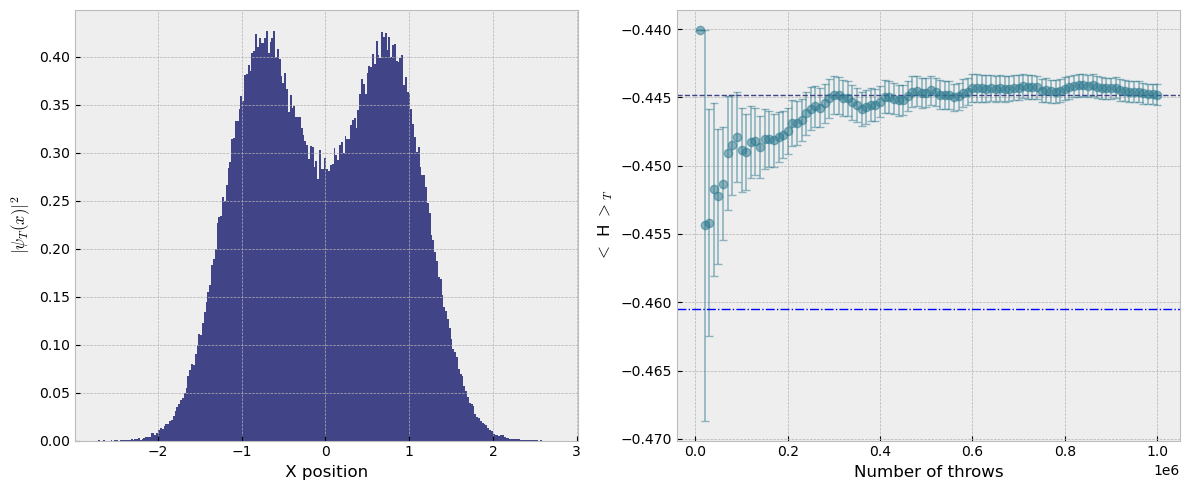

DIAGONALIZATION with PYTHON
Ground state energy:  -0.4604658796923901
1st excited state energy:  0.09742471331806084
2nd excited state energy:  1.9717331343935816
Montecarlo method
GS energy:  -0.444795 $\pm$ 0.000745191


In [167]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

plt.style.use('bmh')
mpl.rcParams['font.size'] = 10
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['axes.titlesize'] = 12
mpl.rcParams['legend.fontsize'] = 10
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['lines.markersize'] = 6

viridis = plt.cm.viridis
color_1 = viridis(0.2)
color_2 = viridis(0.4)

file_avg = "sampling.data"
x = np.loadtxt(file_avg, usecols=(0), delimiter='\t', unpack=True)
file_hamiltonian = "ave_hamiltonian.data"
x1,y1,error1 = np.loadtxt(file_hamiltonian, usecols=(0, 1, 2), delimiter='\t', unpack=True)
fig, axs = plt.subplots(1,2,figsize=(12, 5))

axs[0].hist(x,bins=250, color=color_1, density=True)
axs[0].set_xlabel(' X position ')
axs[0].set_ylabel(rf'$|\psi_T(x)|^2$')

axs[1].errorbar(x1,y1,error1, fmt='o', color=color_2,capsize=3, elinewidth=1.2, alpha=0.5)
axs[1].axhline(y=y1[99], color=color_1, linestyle='--', lw=1, label='Montecarlo GS energy')
axs[1].axhline(y=E[0], color='b', linestyle='-.', lw=1, label='Python GS energy')
axs[1].set_xlabel('Number of throws')
axs[1].set_ylabel(rf'$<$ H $>_T$')
plt.tight_layout()
plt.show()

print("===================================================================")
print("DIAGONALIZATION with PYTHON")
print("===================================================================")
print("Ground state energy: ", E[0])
print("1st excited state energy: ", E[1])
print("2nd excited state energy: ", E[2])
print("===================================================================")
print("Montecarlo method")
print("===================================================================")
print("GS energy: ", y1[99], r"$\pm$", error1[99])
print("===================================================================")





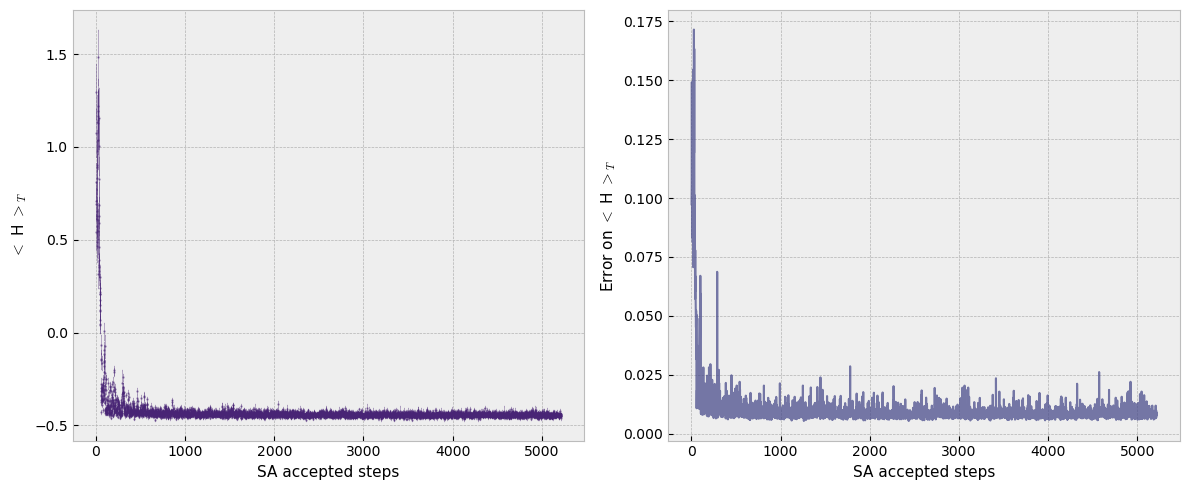

In [168]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

# Stile compatto
mpl.rcParams['font.size'] = 10
mpl.rcParams['axes.labelsize'] = 11
mpl.rcParams['axes.titlesize'] = 12
mpl.rcParams['legend.fontsize'] = 9
mpl.rcParams['lines.linewidth'] = 1.5
mpl.rcParams['lines.markersize'] = 5

# Load data
file1 = "ave_hamiltonian_sa_steps.data"
x1, y1, error1 = np.loadtxt(file1, usecols=(0, 3, 4), delimiter='\t', unpack=True, skiprows=1)
x2, y2 = np.loadtxt(file1, usecols=(0, 4), delimiter='\t', unpack=True, skiprows=1)

viridis = plt.cm.viridis
color_std = viridis(0.1)  
color_err = viridis(0.2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].errorbar(x1, y1, yerr=error1, fmt='o', color=color_std,
                 capsize=0.2, elinewidth=0.5, alpha=0.5, markersize=0.7)

axes[0].set_xlabel('SA accepted steps')
axes[0].set_ylabel(rf'$<$ H $>_T$')
axes[0].grid(True)

axes[1].plot(x2, y2, '-', color=color_err, alpha=0.7, label='Error')
axes[1].set_xlabel('SA accepted steps')
axes[1].set_ylabel(rf'Error on $<$ H $>_T$')
axes[1].grid(True)

plt.tight_layout()
plt.show()


ValueError: x and y must have same first dimension, but have shapes (1000000,) and (1000,)

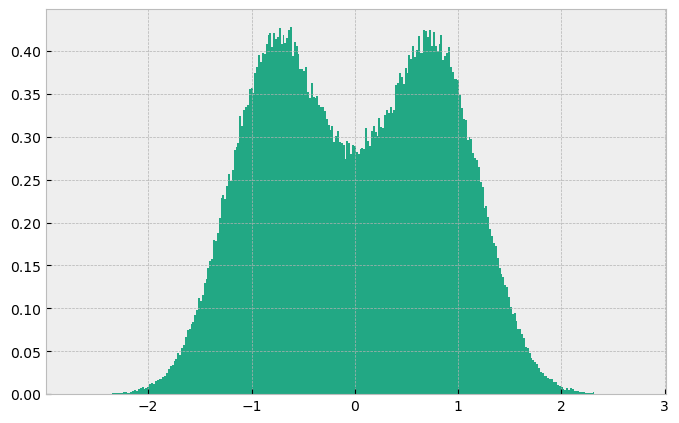

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

plt.style.use('bmh')
mpl.rcParams['font.size'] = 10
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['axes.titlesize'] = 12
mpl.rcParams['legend.fontsize'] = 10
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['lines.markersize'] = 6

# Colori
viridis = plt.cm.viridis
color_1 = viridis(0.2)
color_2 = viridis(0.4)
color_3 = viridis(0.6) 

data = np.loadtxt("output_SA.txt")
best_mu = data[len(data)-1, 1]
best_sigma = data[len(data)-1, 2]

def PsiSquare(x, mu, sigma):
    return (np.exp(-(x - mu)**2 / (2.0 * sigma**2)) + np.exp(-(x + mu)**2 / (2.0 * sigma**2)))**2

histo_data = np.loadtxt("sampling.data")

plt.figure(figsize=(8,5))
plt.hist(histo_data, bins=300, density=True, color=color_3, label='Metropolis sampling')
#plt.plot(x, psi[0]*psi[0], color=color_1, label=rf'Analytical $\Psi^2$', lw=1, linestyle='-.')

plt.ylabel("Wavefunction square modulus")
plt.xlabel("X position")
plt.xlim((-2.9, 2.9))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
